In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

df = pd.read_csv(
    "Donnee_compteur_SEP.csv",
    sep=";",
    encoding="cp1252"
)

df.columns = df.columns.str.strip().str.replace("\n", "").str.replace("\r", "")

df["Horodatage"] = pd.to_datetime(df["Horodatage"], dayfirst=True)
df = df.sort_values("Horodatage")
print(df.columns)

Index(['Horodatage', 'NOG 2SEP992QD', 'NOG 2SEP992QD_Qualite', 'NOG 1SEP992QD',
       'NOG 1SEP992QD_Qualite', 'NOG 0SEP998QD', 'NOG 0SEP998QD_Qualite',
       'NOG 0SEP999QD', 'NOG 0SEP999QD_Qualite', 'NOG 1SEP991QD',
       'NOG 1SEP991QD_Qualite', 'NOG 2SEP991QD', 'NOG 2SEP991QD_Qualite'],
      dtype='object')


In [32]:
compteurs = [
    c for c in df.columns
    if "_" not in c and c != "Horodatage"
]

In [33]:
data_all = []

for compteur in compteurs:

    q_col = f"{compteur}_Qualite"

    if compteur not in df.columns or q_col not in df.columns:
        continue

    d = df[["Horodatage", compteur, q_col]].copy()

    # garder uniquement GOOD
    d = d[d[q_col] == "GOOD"]

    # conversion propre
    d[compteur] = pd.to_numeric(d[compteur], errors="coerce")

    # supprimer NaN
    d = d.dropna(subset=[compteur])

    # calcul consommation
    d["delta_val"] = d[compteur].diff()
    d["delta_t"] = d["Horodatage"].diff().dt.days

    d["conso_jour"] = d["delta_val"] / d["delta_t"]

    # nettoyage logique
    d = d.dropna()
    d = d[d["conso_jour"] >= 0]

    d["capteur"] = compteur

    data_all.append(d)

df_conso = pd.concat(data_all, ignore_index=True)

In [34]:
df_conso["conso_log"] = np.log1p(df_conso["conso_jour"])

model = IsolationForest(
    n_estimators=300,
    random_state=42
)

df_conso["anomaly"] = model.fit_predict(df_conso[["conso_log"]])
df_conso["score"] = model.decision_function(df_conso[["conso_log"]])

In [35]:
def compute_levels(group):
    return pd.Series({
        "q90": group["score"].quantile(0.10),
        "q97": group["score"].quantile(0.03),
        "q99": group["score"].quantile(0.01),
    })

thresholds = df_conso.groupby("capteur").apply(compute_levels)
df_conso = df_conso.join(thresholds, on="capteur")

/tmp/ipykernel_4108/1985510480.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  thresholds = df_conso.groupby("capteur").apply(compute_levels)


In [36]:
def alert(row):
    if row["score"] < row["q99"]:
        return "🔴 ROUGE"
    elif row["score"] < row["q97"]:
        return "🟠 ORANGE"
    elif row["score"] < row["q90"]:
        return "🟡 JAUNE"
    return "NORMAL"

df_conso["alerte"] = df_conso.apply(alert, axis=1)

In [37]:
print("Nb total de points :", len(df_conso))
print("Nb de capteurs :", df_conso["capteur"].nunique())

Nb total de points : 2209
Nb de capteurs : 6


In [38]:
df_conso["alerte"].value_counts()

,count
alerte,
NORMAL,2111
🟡 JAUNE,62
🔴 ROUGE,21
🟠 ORANGE,15


In [39]:
capteur_test = "NOG 1SEP992QD"

df_conso[df_conso["capteur"] == capteur_test][
    ["Horodatage", "conso_jour", "score", "alerte"]
].sort_values("Horodatage")

,Horodatage,conso_jour,score,alerte
358,2020-01-02 21:00:00,0.500000,-0.025608,🔴 ROUGE
359,2020-01-09 21:12:00,0.857143,0.159870,NORMAL
360,2020-01-16 21:22:00,0.000000,-0.008911,NORMAL
361,2020-01-23 21:14:00,2.166667,0.171859,NORMAL
362,2020-01-30 21:09:00,1.166667,0.171859,NORMAL
...,...,...,...,...
774,2025-12-18 23:10:00,inf,0.171859,NORMAL
775,2025-12-25 07:23:00,0.000000,-0.008911,NORMAL
776,2025-12-25 22:27:00,inf,0.171859,NORMAL
777,2026-01-01 08:13:00,0.000000,-0.008911,NORMAL


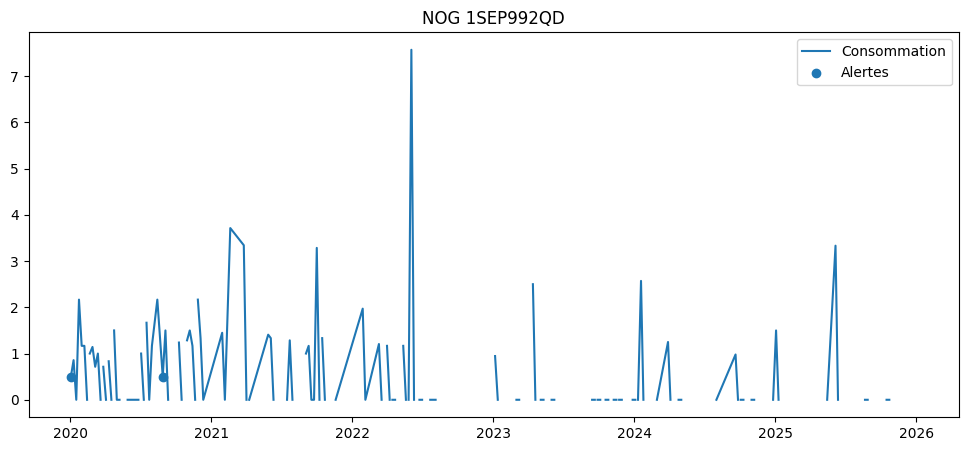

In [40]:
import matplotlib.pyplot as plt

d = df_conso[df_conso["capteur"] == capteur_test]

plt.figure(figsize=(12,5))
plt.plot(d["Horodatage"], d["conso_jour"], label="Consommation")
plt.scatter(
    d[d["alerte"] != "NORMAL"]["Horodatage"],
    d[d["alerte"] != "NORMAL"]["conso_jour"],
    label="Alertes"
)
plt.legend()
plt.title(capteur_test)
plt.show()

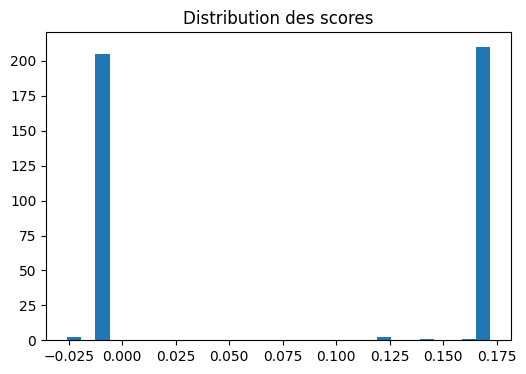

In [41]:
plt.figure(figsize=(6,4))
plt.hist(d["score"], bins=30)
plt.title("Distribution des scores")
plt.show()

In [42]:
split_date = df_conso["Horodatage"].quantile(0.7)

train = df_conso[df_conso["Horodatage"] <= split_date]
test  = df_conso[df_conso["Horodatage"] > split_date]

model = IsolationForest(n_estimators=300, random_state=42)
model.fit(train[["conso_log"]])

test["score"] = model.decision_function(test[["conso_log"]])

/tmp/ipykernel_4108/2961512669.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["score"] = model.decision_function(test[["conso_log"]])


In [43]:
d_sim = d.copy()
d_sim.loc[d_sim.index[-3:], "conso_jour"] *= 3
d_sim["conso_log"] = np.log1p(d_sim["conso_jour"])

d_sim["score_sim"] = model.decision_function(d_sim[["conso_log"]])